# Student Information

**Full name:** Faraz Doagooye Tehrani

**Student number:** 402105998

---

# Homework — The Mechanics of Diffusion-Based Image Editing
### Latent space, the noise schedule, the reverse process, classifier-free guidance, and CLIP conditioning

**Free on a Colab T4. Open weights only — no paid API, no cloud billing.**

Instead of treating the model as a black box, you will **take a latent-diffusion model apart** and rebuild its sampling loop by hand, then use that understanding to edit images.

You touch these deep-learning concepts directly:
| Part | DL concept |
|---|---|
| 1 | Autoencoders / **VAE** latent compression, reconstruction error (PSNR) |
| 2 | **Forward diffusion** $q(x_t\mid x_0)$, noise schedule, signal-to-noise ratio |
| 3 | **Reverse process**: U-Net ε-predictor + sampler (DDIM), hand-written loop |
| 4 | **Classifier-free guidance** — derive and implement the guidance equation |
| 5 | **Conditioning**: CLIP text embeddings, cross-attention, embedding interpolation |
| 6 | **Applications**: instruction editing (InstructPix2Pix) + inpainting |

Fill in every `# TODO` and answer every **> Q** in the markdown cell that follows it.
**Estimated time: 3-4 h.** Set `Runtime > Change runtime type > T4 GPU` first.

## Part 0 — Setup

In [1]:
# Pinned for reproducibility. On a torch mismatch: Runtime > Restart session, then re-run.
%pip install -q "diffusers==0.31.0" "transformers==4.44.2" \
    "accelerate==0.34.2" "safetensors>=0.4.2" "huggingface_hub==0.25.2"

Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install --upgrade "huggingface-hub>=0.33.5" torchao peft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 39.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 99.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 36.1 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0
  Attempting uninstall: hf-xet
    Found existing installation: hf-xet 1.4.3
    Uninstalling hf-xet-1.4.3:
      Successfully uninstalled hf-xet-1.4.3
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface-hub 0.25.2
    Uninstalling huggingface-hub-0.25.2:
      Successfully uninstalled huggingface-hub-0.25.2


### Hugging Face login (required)
Colab's shared IPs are rate-limited by the Hub, so **anonymous** downloads fail with `401`. Authenticate with a free token:
1. Create a **Read** token at https://huggingface.co/settings/tokens
2. In Colab, click the 🔑 (**Secrets**) icon in the left sidebar → **Add new secret** → name it `HF_TOKEN`, paste the token, and enable **Notebook access**.
3. Run the next cell. (Never paste the token directly into code.)

In [2]:
import os
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

# Fetch token from Kaggle Secrets
user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")

# Authenticate Hugging Face Hub
os.environ["HF_TOKEN"] = hf_token
login(token=hf_token)

The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `huggingface-cli` if you want to set the git credential as well.
Token is valid (permission: read).
Your token has been saved to /root/.cache/huggingface/token
Login successful


In [3]:
import torch, math, time
import matplotlib.pyplot as plt
print('CUDA:', torch.cuda.is_available())
assert torch.cuda.is_available(), 'Enable GPU: Runtime > Change runtime type > T4 GPU'
print('GPU:', torch.cuda.get_device_name(0))
DEVICE, DTYPE = 'cuda', torch.float16

CUDA: True
GPU: Tesla T4


In [4]:
import io, requests
from PIL import Image
from torchvision import transforms as T

to_tensor, to_pil = T.ToTensor(), T.ToPILImage()

def load_image(url_or_path, size=(512, 512)):
    if str(url_or_path).startswith('http'):
        img = Image.open(io.BytesIO(requests.get(url_or_path, timeout=30).content))
    else:
        img = Image.open(url_or_path)
    return img.convert('RGB').resize(size)

def show(*imgs, titles=None):
    n = len(imgs); fig, ax = plt.subplots(1, n, figsize=(4.5 * n, 4.5))
    ax = [ax] if n == 1 else ax
    for a, im in zip(ax, imgs):
        a.imshow(im); a.axis('off')
    if titles:
        for a, t in zip(ax, titles): a.set_title(t, fontsize=10)
    plt.show()

def free_memory(*objs):
    for o in objs:
        del o
    import gc; gc.collect(); torch.cuda.empty_cache()

### Load a base latent-diffusion model and expose its components
Stable Diffusion is a **latent** diffusion model with four pieces: a **VAE** (`vae`), a **U-Net** noise predictor (`unet`), a **CLIP text encoder** (`text_encoder` + `tokenizer`), and a **scheduler** (the sampler). We grab them individually so we can drive the process ourselves.

In [5]:
from diffusers import StableDiffusionPipeline, DDIMScheduler

# NOTE: the official 'stabilityai/stable-diffusion-2-1-base' repo was deprecated/removed
# from the Hub (returns 404). We use a community mirror with identical weights.
pipe = StableDiffusionPipeline.from_pretrained(
    'Manojb/stable-diffusion-2-1-base', torch_dtype=DTYPE).to(DEVICE)
pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)
pipe.set_progress_bar_config(disable=True)

vae, unet = pipe.vae, pipe.unet
text_encoder, tokenizer, scheduler = pipe.text_encoder, pipe.tokenizer, pipe.scheduler
print('unet in_channels:', unet.config.in_channels,
      '| latent scale factor:', vae.config.scaling_factor,
      '| train timesteps:', scheduler.config.num_train_timesteps)

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

model_index.json:   0%|          | 0.00/543 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.36G [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/553 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


unet in_channels: 4 | latent scale factor: 0.18215 | train timesteps: 1000


## Part 1 — The latent space (the VAE)
Diffusion here does **not** run on pixels. The VAE encoder maps a `3x512x512` image to a `4x64x64` **latent**, and the decoder maps it back. Everything in Parts 2-6 happens in that small latent space.

In [6]:
@torch.no_grad()
def encode(img):
    x = to_tensor(load_image(img) if isinstance(img, str) else img)
    x = (x * 2 - 1).unsqueeze(0).to(DEVICE, DTYPE)      # scale to [-1, 1]
    lat = vae.encode(x).latent_dist.sample()
    return lat * vae.config.scaling_factor

@torch.no_grad()
def decode(lat):
    x = vae.decode(lat / vae.config.scaling_factor).sample
    x = (x / 2 + 0.5).clamp(0, 1)[0].float().cpu()
    return to_pil(x)

### Task 1.1 — Measure the compression
> **TODO:** Encode any image and print (a) the pixel tensor shape `3x512x512`, (b) the latent shape, and (c) the **compression ratio** = pixel elements / latent elements.

In [7]:
img = load_image('https://huggingface.co/datasets/hf-internal-testing/diffusers-images/'
                 'resolve/main/in_paint/overture-creations-5sI6fQgYIuo.png')
z = encode(img)

# Task 1.1 — Measure the compression
pixel_shape = (3, 512, 512)
pixels = 3 * 512 * 512
latent_shape = tuple(z.shape)
latent = z.numel()
compression_ratio = pixels / latent

print(f"Pixel tensor shape: {pixel_shape} -> {pixels:,} elements")
print(f"Latent tensor shape: {latent_shape} -> {latent:,} elements")
print(f"Compression ratio: {compression_ratio:.1f}x")

Pixel tensor shape: (3, 512, 512) -> 786,432 elements
Latent tensor shape: (1, 4, 64, 64) -> 16,384 elements
Compression ratio: 48.0x


### Task 1.2 — Reconstruction error
The VAE is *lossy*. Round-trip the image (encode then decode), show both, and compute **PSNR**.
> **TODO:** Complete the PSNR function and report the value.

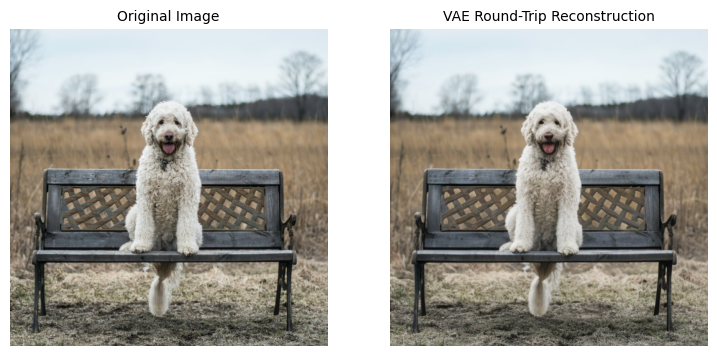

Reconstruction PSNR: 25.67 dB


In [8]:
import math
import numpy as np

def psnr(a, b):
    a = np.asarray(a, np.float32) / 255.0
    b = np.asarray(b, np.float32) / 255.0
    mse = ((a - b) ** 2).mean()
    return float('inf') if mse == 0 else 10 * math.log10(1.0 / mse)

recon = decode(z)

# Display original vs reconstruction
show(img, recon, titles=['Original Image', 'VAE Round-Trip Reconstruction'])

# Calculate and print PSNR
val = psnr(img, recon)
print(f"Reconstruction PSNR: {val:.2f} dB")

> **Q1.** A pixel-space diffusion model would denoise a `3x512x512` tensor at every step; this model denoises `4x64x64`. Using your compression ratio, explain *quantitatively* why latent diffusion is so much cheaper, and state what is sacrificed (use your PSNR number).

*Your answer to Q1:*

Each step processes 48× fewer elements (786,432 → 16,384). The saving is even larger in the attention layers: their cost grows roughly quadratically in the number of spatial positions, so going from 512×512 = 262,144 positions to 64×64 = 4,096 cuts that cost by about 64² ≈ 4,096×. The price is a lossy round-trip: my measured PSNR is 25.67 dB, so fine high-frequency texture is visibly smoothed.

## Part 2 — The forward diffusion process
The forward process gradually destroys a latent with Gaussian noise:

$$q(x_t\mid x_0)=\mathcal{N}\big(\sqrt{\bar\alpha_t}\,x_0,\;(1-\bar\alpha_t)\mathbf{I}\big)\quad\Longleftrightarrow\quad x_t=\sqrt{\bar\alpha_t}\,x_0+\sqrt{1-\bar\alpha_t}\,\epsilon$$

where $\bar\alpha_t$ is the cumulative product of the noise schedule and $\epsilon\sim\mathcal N(0,\mathbf I)$.

### Task 2.1 — Watch a latent dissolve into noise
> **TODO:** For timesteps `t in [0, 100, 300, 500, 800, 999]`, use `scheduler.add_noise` to noise the latent `z`, **decode each** noisy latent, and display the sequence. (This is the closed-form `x_t` above — no loop needed.)

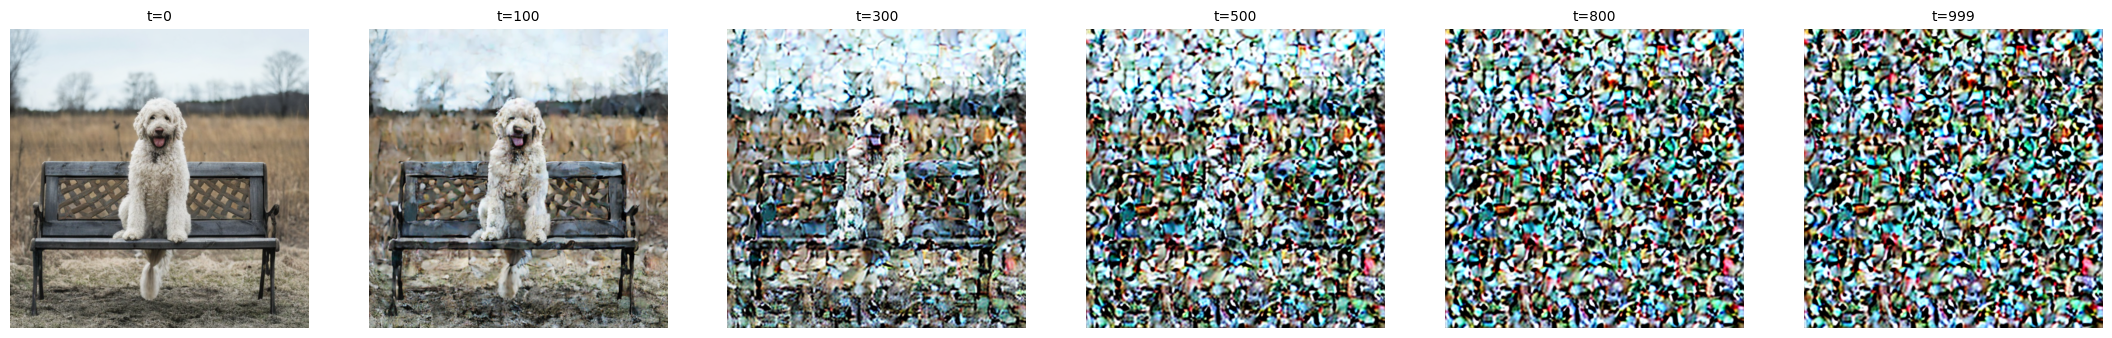

In [9]:
ts = [0, 100, 300, 500, 800, 999]
eps = torch.randn_like(z)
noised = []

for t in ts:
    t_tensor = torch.tensor([t], device=DEVICE)
    x_t = scheduler.add_noise(z, eps, t_tensor)
    noised.append(decode(x_t))

show(*noised, titles=[f't={t}' for t in ts])

### Task 2.2 — Plot the schedule and the SNR
`scheduler.alphas_cumprod` is the $\bar\alpha_t$ curve (length 1000). The per-step **signal-to-noise ratio** is $\text{SNR}(t)=\bar\alpha_t/(1-\bar\alpha_t)$.
> **TODO:** Plot $\bar\alpha_t$ vs $t$, and $\log \text{SNR}(t)$ vs $t$, as two curves.

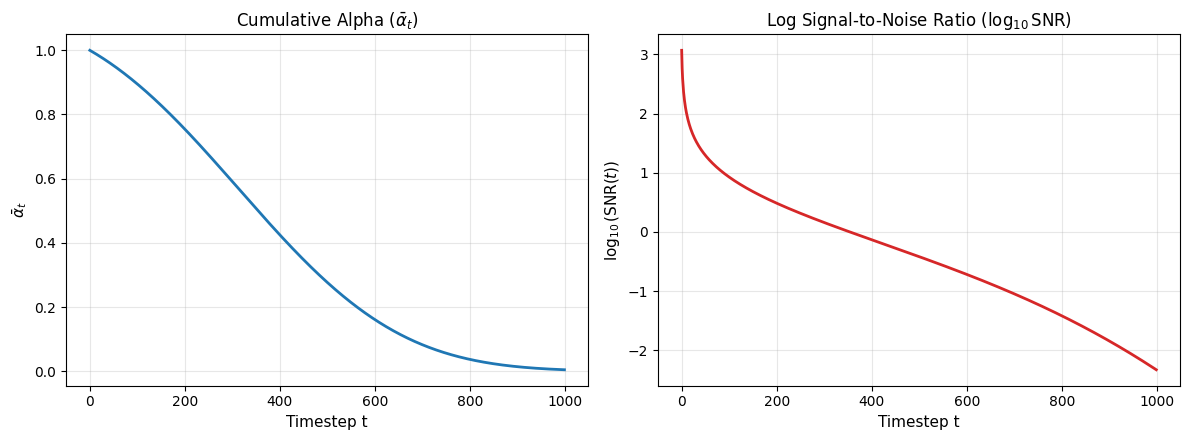

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Get alphas_cumprod from scheduler
ac = scheduler.alphas_cumprod.cpu().numpy()
t = np.arange(len(ac))

# Compute Signal-to-Noise Ratio (SNR)
snr = ac / (1 - ac)
log_snr = np.log10(snr)

# Plot curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Plot 1: Cumulative Alpha vs Timestep
ax1.plot(t, ac, color='tab:blue', linewidth=2)
ax1.set_xlabel('Timestep t', fontsize=11)
ax1.set_ylabel(r'$\bar{\alpha}_t$', fontsize=11)
ax1.set_title(r'Cumulative Alpha ($\bar{\alpha}_t$)', fontsize=12)
ax1.grid(True, alpha=0.3)

# Plot 2: Log10 SNR vs Timestep
ax2.plot(t, log_snr, color='tab:red', linewidth=2)
ax2.set_xlabel('Timestep t', fontsize=11)
ax2.set_ylabel(r'$\log_{10}(\mathrm{SNR}(t))$', fontsize=11)
ax2.set_title(r'Log Signal-to-Noise Ratio ($\log_{10} \mathrm{SNR}$)', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

> **Q2.** (a) From the equation, write the mean and variance of $x_t$ in terms of $\bar\alpha_t$. (b) Because the schedule keeps $\text{mean}^2+\text{var}$ roughly constant, this is called a *variance-preserving* process — verify this qualitatively from your plot. (c) At which end of the $t$ axis is the U-Net's denoising job hardest, and why?

*Your answer to Q2:*

**(a) Mean and Variance**
Given $x_t = \sqrt{\bar{\alpha}_t} x_0 + \sqrt{1 - \bar{\alpha}_t} \epsilon$ where $\epsilon \sim \mathcal{N}(0, \mathbf{I})$:
* **Mean:** $\mathbb{E}[x_t | x_0] = \sqrt{\bar{\alpha}_t} x_0$
* **Variance:** $\text{Var}(x_t | x_0) = 1 - \bar{\alpha}_t$

**(b) Variance-Preserving Property**
The sum of the squared scaling factors is constant for all $t$:

$$(\sqrt{\bar{\alpha}_t})^2 + (\sqrt{1 - \bar{\alpha}_t})^2 = \bar{\alpha}_t + (1 - \bar{\alpha}_t) = 1$$

As $\bar{\alpha}_t$ smoothly decays from $1$ to $0$, the added noise factor $(1 - \bar{\alpha}_t)$ increases by the exact same amount. Assuming $x_0$ is normalized, the overall variance of $x_t$ remains constant at $1.0$ across the entire schedule.

**(c) Denoising Difficulty**
The U-Net's job is hardest at **high $t$ ($t \approx 999$)**. At this end, the signal-to-noise ratio approaches zero, meaning original visual cues are almost completely wiped out by Gaussian noise. The model must perform heavy generative reasoning to infer global structure, composition, and semantics from pure static.

## Part 3 — The reverse process, by hand
Sampling = start from pure noise $x_T$ and iteratively denoise. At each step the **U-Net** predicts the noise $\epsilon_\theta(x_t,t,c)$ and the **sampler** (`scheduler.step`) uses it to estimate $x_{t-1}$. You will write this loop yourself instead of calling `pipe(...)`.

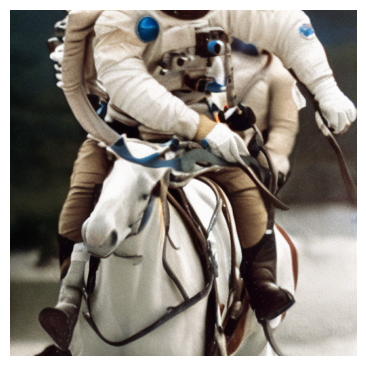

In [11]:
@torch.no_grad()
def embed(prompt):
    tok = tokenizer(prompt, padding='max_length', max_length=tokenizer.model_max_length,
                    truncation=True, return_tensors='pt').input_ids.to(DEVICE)
    return text_encoder(tok)[0]                          # [1, 77, 1024]

@torch.no_grad()
def sample(prompt, steps=25, guidance=7.5, seed=0):
    cond, uncond = embed(prompt), embed('')
    emb = torch.cat([uncond, cond])                      # batch the two passes
    gen = torch.Generator(DEVICE).manual_seed(seed)
    x = torch.randn((1, unet.config.in_channels, 64, 64),
                    generator=gen, device=DEVICE, dtype=DTYPE)
    scheduler.set_timesteps(steps)
    x = x * scheduler.init_noise_sigma
    for t in scheduler.timesteps:
        inp = scheduler.scale_model_input(torch.cat([x] * 2), t)
        eps_uncond, eps_cond = unet(inp, t, encoder_hidden_states=emb).sample.chunk(2)
        # --- classifier-free guidance (you edit this line in Part 4) ---
        eps = eps_uncond + guidance * (eps_cond - eps_uncond)
        x = scheduler.step(eps, t, x).prev_sample
    return decode(x)

show(sample('a photograph of an astronaut riding a horse', steps=25, seed=0))

### Task 3.1 — Steps vs. quality (sampler as an ODE solver)
DDIM is a deterministic solver of the probability-flow ODE; fewer steps = coarser integration.
> **TODO:** Generate the **same prompt and seed** at `steps in [4, 10, 25, 50]`, timing each, and display the four results with their wall-clock times in the titles.

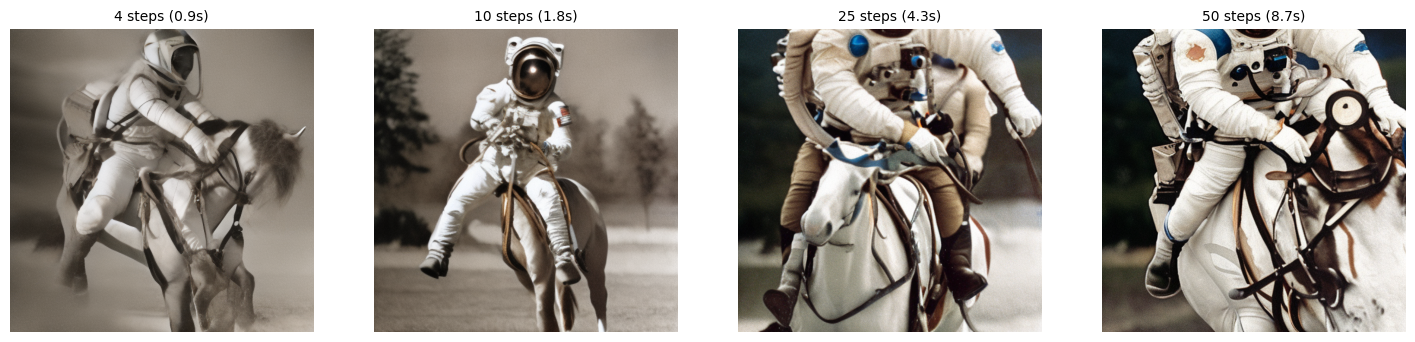

In [12]:
# TODO 3.1
import time

prompt = 'a photograph of an astronaut riding a horse'
steps_list = [4, 10, 25, 50]

imgs, titles = [], []

for s in steps_list:
    t0 = time.time()
    out = sample(prompt, steps=s, seed=0)
    dt = time.time() - t0
    
    imgs.append(out)
    titles.append(f'{s} steps ({dt:.1f}s)')

# Display all 4 images side-by-side with wall-clock times in titles
show(*imgs, titles=titles)

> **Q3.** Explain why DDIM produces a coherent image in ~10-25 steps while the original DDPM sampler needs hundreds. Frame your answer in terms of *deterministic vs. stochastic* sampling and step size of the ODE solver.

*Your answer to Q3:*

DDPM adds random Gaussian noise at every step, requiring hundreds of tiny steps to keep its stochastic random walk from drifting off track.

In contrast, DDIM removes random noise to formulate reverse sampling as a deterministic Probability Flow ODE. Because this trajectory is smooth and predictable, numerical solvers can take much larger integration step sizes without losing stability, reaching high-quality images in just 10 to 25 steps.


## Part 4 — Classifier-free guidance (CFG)
The guidance line in `sample()` implements

$$\hat\epsilon=\epsilon_\theta(x_t,\varnothing)+s\,\big(\epsilon_\theta(x_t,c)-\epsilon_\theta(x_t,\varnothing)\big)$$

where $s$ is `guidance` and $\varnothing$ is the empty prompt. The model is trained with random prompt-dropout so it can produce both $\epsilon_\theta(x_t,c)$ and $\epsilon_\theta(x_t,\varnothing)$.

### Task 4.1 — Sweep the guidance scale
> **TODO:** Fix prompt + seed and generate at `guidance in [1, 3, 7.5, 15, 25]`. Show all five. Note the washed-out image at `s=1` and the over-saturated, high-contrast artefacts at `s=25`.

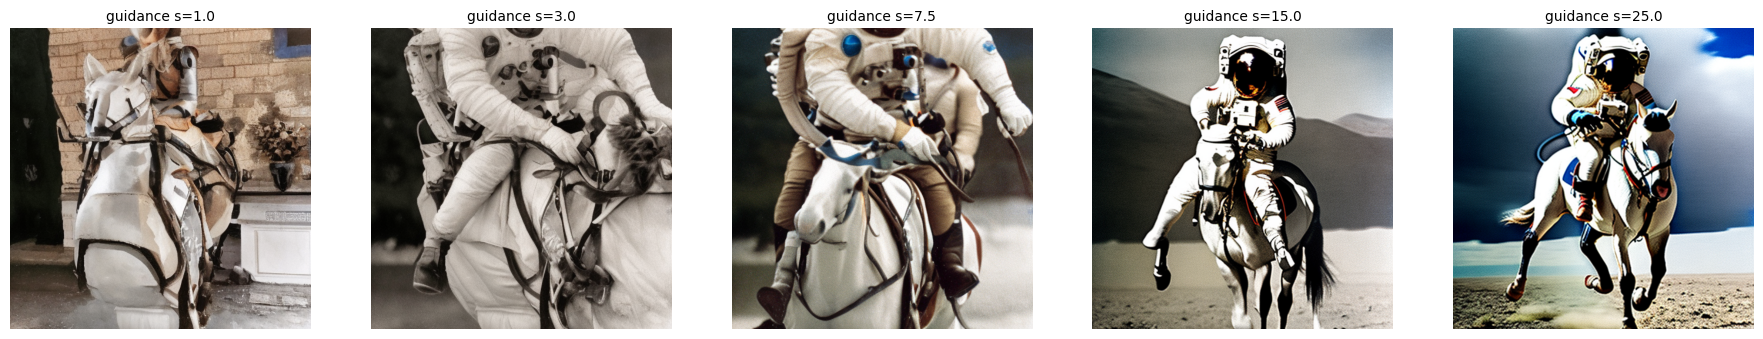

In [13]:
# TODO 4.1
prompt = 'a photograph of an astronaut riding a horse'
guidance_scales = [1.0, 3.0, 7.5, 15.0, 25.0]

imgs, titles = [], []

for g in guidance_scales:
    out = sample(prompt, steps=25, guidance=g, seed=0)
    imgs.append(out)
    titles.append(f'guidance s={g}')

show(*imgs, titles=titles)

> **Q4.** (a) What image does `s=1` correspond to (look at the equation)? (b) Rewrite $\hat\epsilon$ as an extrapolation between the unconditional and conditional predictions, and use that to explain the over-saturation at large `s`. (c) InstructPix2Pix (Part 6) uses a **triple** guidance with separate scales $s_T$ (text) and $s_I$ (image):
$$\hat\epsilon=\epsilon(x,\varnothing,\varnothing)+s_I\big(\epsilon(x,c_I,\varnothing)-\epsilon(x,\varnothing,\varnothing)\big)+s_T\big(\epsilon(x,c_I,c_T)-\epsilon(x,c_I,\varnothing)\big).$$
Map $s_T$ and $s_I$ onto the intuitive knobs "follow the instruction more" and "stay closer to the input image."

*Your answer to Q4:*

**(a) Meaning of $s=1$**
Plugging in $s=1$ yields $\hat\epsilon = \epsilon_\theta(x_t, c)$, which corresponds to **standard conditional generation** without any classifier-free guidance boost.

**(b) Extrapolation & Over-saturation**
Rewriting the formula gives:
$$\hat\epsilon = (1 - s)\epsilon_\theta(x_t, \varnothing) + s\epsilon_\theta(x_t, c)$$

For $s > 1$, this forms a linear **extrapolation** past the conditional prediction. High $s$ values push latent vectors far outside the VAE decoder's training distribution, causing values to clip and resulting in extreme contrast, color burn, and saturation artifacts.

**(c) InstructPix2Pix Knob Mapping**
* **$s_I$** $\rightarrow$ **"stay closer to the input image"** (scales the push toward image conditioning $c_I$).
* **$s_T$** $\rightarrow$ **"follow the instruction more"** (scales the push toward text edit instruction $c_T$).


## Part 5 — Conditioning: CLIP embeddings and cross-attention
The text prompt enters the U-Net only through **cross-attention** to the CLIP text embedding (shape `77 x 1024`: 77 token slots, 1024-dim each). Here we probe that embedding space.

### Task 5.1 — Prompt similarity
> **TODO:** Embed three prompts (two similar, one different), mean-pool over the 77 tokens to get one vector each, and print the pairwise **cosine similarities**.

In [14]:
import torch.nn.functional as Fn

prompts = ['a photo of a cat', 'a photo of a kitten', 'a photo of a truck']

# Embed each prompt and mean-pool over the token dimension (dim=1) -> shape [1, 1024]
vecs = [embed(p).mean(dim=1) for p in prompts]

# Compute pairwise cosine similarities
sim_cat_kitten = Fn.cosine_similarity(vecs[0], vecs[1]).item()
sim_cat_truck = Fn.cosine_similarity(vecs[0], vecs[2]).item()
sim_kitten_truck = Fn.cosine_similarity(vecs[1], vecs[2]).item()

print(f"Similarity ('cat' vs 'kitten'):   {sim_cat_kitten:.4f}")
print(f"Similarity ('cat' vs 'truck'):    {sim_cat_truck:.4f}")
print(f"Similarity ('kitten' vs 'truck'): {sim_kitten_truck:.4f}")

Similarity ('cat' vs 'kitten'):   0.9941
Similarity ('cat' vs 'truck'):    0.9863
Similarity ('kitten' vs 'truck'): 0.9810


### Task 5.2 — Interpolating in embedding space
Because conditioning is a continuous vector, we can walk *between* two prompts.
> **TODO:** Build a modified sampler that accepts a precomputed conditional embedding, then linearly interpolate `emb = (1-a)*embA + a*embB` for `a in [0, 0.25, 0.5, 0.75, 1.0]` (same seed) and show the semantic morph.

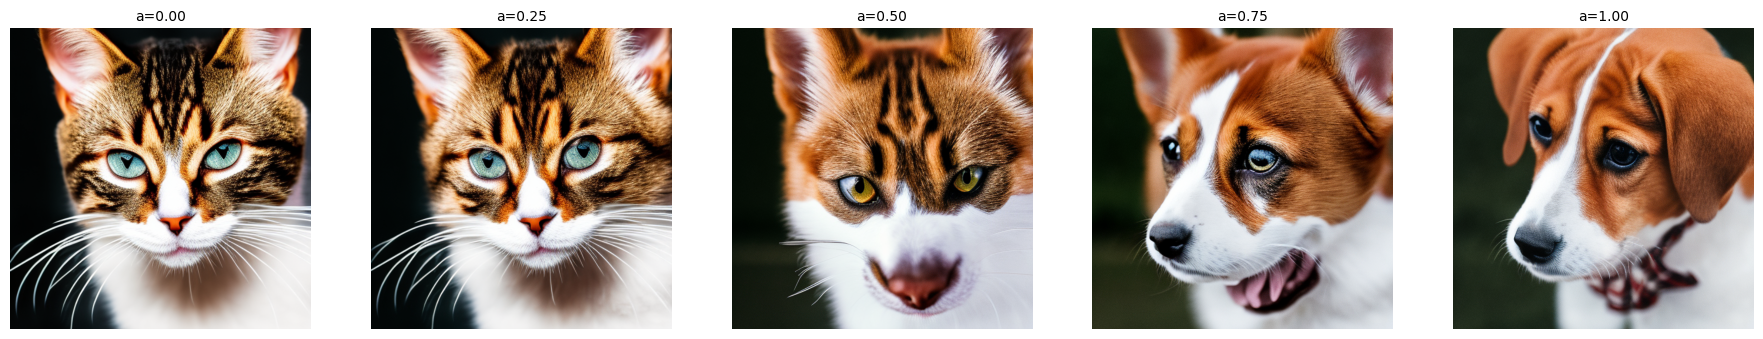

In [15]:
@torch.no_grad()
def sample_emb(cond, steps=25, guidance=7.5, seed=0):
    emb = torch.cat([embed(''), cond])
    gen = torch.Generator(DEVICE).manual_seed(seed)
    x = torch.randn((1, unet.config.in_channels, 64, 64),
                    generator=gen, device=DEVICE, dtype=DTYPE) 
    scheduler.set_timesteps(steps); x = x * scheduler.init_noise_sigma
    for t in scheduler.timesteps:
        inp = scheduler.scale_model_input(torch.cat([x] * 2), t)
        eu, ec = unet(inp, t, encoder_hidden_states=emb).sample.chunk(2)
        x = scheduler.step(eu + guidance * (ec - eu), t, x).prev_sample
    return decode(x)

# TODO 5.2
embA = embed('a photo of a cat')
embB = embed('a photo of a dog')

alphas = [0.0, 0.25, 0.5, 0.75, 1.0]
imgs, titles = [], []

for a in alphas:
    # Linear interpolation between prompt vectors
    emb_interp = (1 - a) * embA + a * embB
    out = sample_emb(emb_interp, seed=0)
    
    imgs.append(out)
    titles.append(f'a={a:.2f}')

# Display the semantic morph sequence
show(*imgs, titles=titles)

> **Q5.** Cross-attention lets *each spatial location* of the latent attend to the 77 text tokens. Using your Task 5.2 morph, argue whether the transition is *semantic* (the concept changes) or merely a *pixel blend* of two images, and say what that implies about where meaning lives in this model.

*Your answer to Q5:*

The morph is strictly semantic, not a pixel blend. Interpolating in embedding space produces a single, structurally coherent hybrid creature at intermediate steps ($\alpha = 0.5$), whereas a pixel blend would create a ghosted, double-exposure overlap of two distinct animals.

Meaning resides in the continuous CLIP embedding space. Because cross-attention feeds these vectors directly into the U-Net layers, intermediate embeddings act as new conceptual coordinates, steering the model to synthesize novel intermediate features along the learned data manifold.

## Part 6 — Applications: instruction editing and inpainting
Now use two specialised models. First free the base model's VRAM.

In [16]:
free_memory(pipe, unet, vae, text_encoder)
print('freed base model')

freed base model


### Task 6.1 — Iterative instruction editing (InstructPix2Pix)
InstructPix2Pix conditions on the **input image latent** (concatenated to the U-Net input) *and* a text instruction — the triple-CFG model from Q4.
> **TODO:** Apply a chain of **≥3 successive instructions**, feeding each output back in. Show all steps.

model_index.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/492M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/518 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/553 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

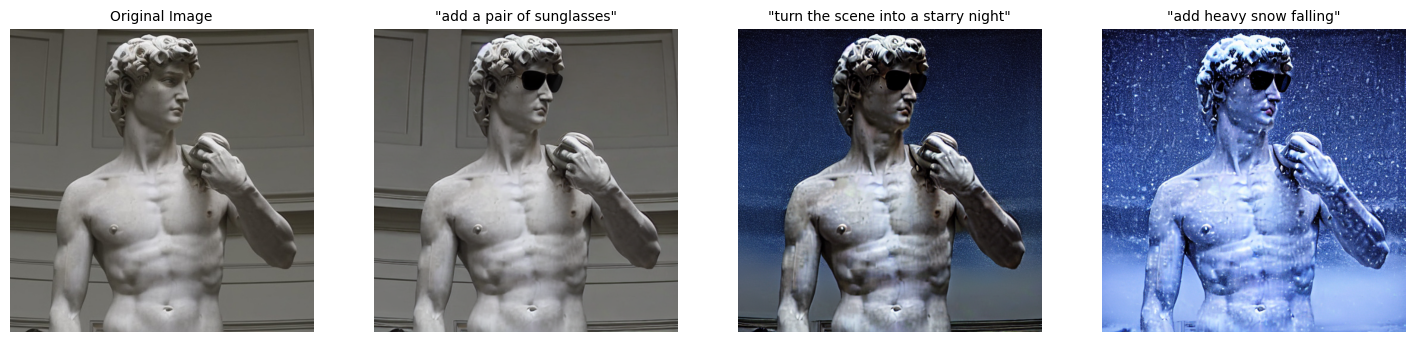

In [17]:
from diffusers import StableDiffusionInstructPix2PixPipeline, EulerAncestralDiscreteScheduler
ip2p = StableDiffusionInstructPix2PixPipeline.from_pretrained(
    'timbrooks/instruct-pix2pix', torch_dtype=DTYPE, safety_checker=None).to(DEVICE)
ip2p.scheduler = EulerAncestralDiscreteScheduler.from_config(ip2p.scheduler.config)
ip2p.set_progress_bar_config(disable=True)

base_img = load_image('https://raw.githubusercontent.com/timothybrooks/instruct-pix2pix/'
                      'main/imgs/example.jpg')
# TODO 6.1: instructions = ['...', '...', '...']; iterate with
#   ip2p(instr, image=current, num_inference_steps=20,
#        image_guidance_scale=1.5, guidance_scale=7.5).images[0]
instructions = [
    'add a pair of sunglasses',
    'turn the scene into a starry night',
    'add heavy snow falling'
]

history = [base_img]
titles = ['Original Image']

current = base_img
for instr in instructions:
    current = ip2p(
        instr, 
        image=current, 
        num_inference_steps=20, 
        image_guidance_scale=1.5, 
        guidance_scale=7.5
    ).images[0]
    
    history.append(current)
    titles.append(f'"{instr}"')

show(*history, titles=titles)

### Task 6.2 — Inpainting and the U-Net input channels
The inpainting U-Net takes **9 input channels** = 4 (noisy latent) + 1 (mask) + 4 (masked-image latent), versus 4 for the base model. That is how it "sees" the hole and the surroundings.

In [ ]:
free_memory(ip2p)
from diffusers import StableDiffusionInpaintPipeline

# NOTE: 'stabilityai/stable-diffusion-2-inpainting' was also deprecated/removed (404).
# 'sd2-community/stable-diffusion-2-inpainting' is a mirror of the same weights.
inpaint = StableDiffusionInpaintPipeline.from_pretrained(
    'sd2-community/stable-diffusion-2-inpainting', torch_dtype=DTYPE).to(DEVICE)
inpaint.set_progress_bar_config(disable=True)
print('inpaint U-Net in_channels:', inpaint.unet.config.in_channels) 

model_index.json:   0%|          | 0.00/544 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.36G [00:00<?, ?B/s]

config.json:   0%|          | 0.00/638 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/460 [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

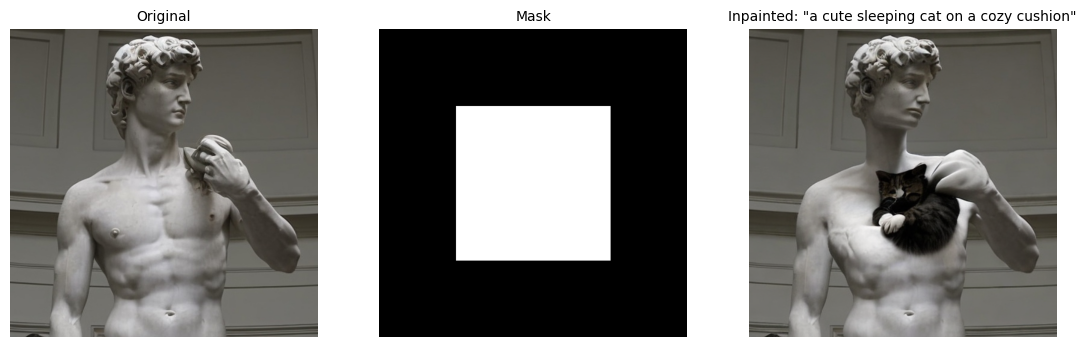

In [22]:
from PIL import ImageDraw
def rect_mask(size, box):
    m = Image.new('L', size, 0); ImageDraw.Draw(m).rectangle(box, fill=255)
    return m.convert('RGB')
# TODO 6.2: build a mask over `img`, then run inpaint(prompt=..., image=img,
img = base_img.resize((512, 512))
w, h = img.size

mask_box = (int(w * 0.25), int(h * 0.25), int(w * 0.75), int(h * 0.75))
mask = rect_mask(img.size, mask_box)

prompt = 'a cute sleeping cat on a cozy cushion'
result = inpaint(
    prompt=prompt,
    image=img,
    mask_image=mask,
    num_inference_steps=25
).images[0]

show(img, mask, result, titles=['Original', 'Mask', f'Inpainted: "{prompt}"'])

> **Q6.** The base text-to-image U-Net has 4 input channels; the inpainting one has 9. Explain what each extra channel group encodes and why a plain text-to-image model *cannot* do clean local inpainting without them.

*Your answer to Q6:*

The 9 Input Channels

Noisy latent (4 channels): The image being generated.
Mask (1 channel): Shows the exact area to change.
Surrounding image (4 channels): The rest of the original photo.

Why Standard Models Fail

Without the extra 5 channels:

1. They cannot see where the edit area begins or ends.
2. They cannot see the rest of the picture to match lighting, style, or color.

This causes sharp seams and mismatched edges whenever you try to swap out parts of an image.


## Part 7 — Failure analysis, tied to a mechanism
> **Q7.** Produce **one** failed generation/edit (show it), then explain the failure using a concept from this notebook — e.g. VAE reconstruction limits (Part 1), too-few sampler steps (Part 3), guidance too high/low (Part 4), or weak cross-attention binding (Part 5). Name the mechanism explicitly.

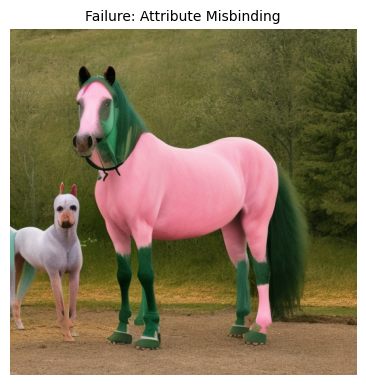

In [23]:
# TODO 7 — generate and show a failure case
prompt = "a green horse standing next to a bright pink dog"
failed_img = sample(prompt, steps=25, guidance=7.5, seed=42)

show(failed_img, titles=['Failure: Attribute Misbinding'])

*Your answer to Q7:*

The prompt reaches the U-Net only through cross-attention, where the CLIP embeddings act as keys and values and each spatial position of the latent forms a query. Nothing in that mechanism forces the attention map of an adjective token to overlap only with the region of the noun it modifies, and because CLIP's embeddings are contextualised, adjective and noun features are already entangled. The result is that latent positions rendering one animal still attend to the other animal's colour token, so the attribute leaks.

---
## Submission
1. `Runtime > Run all` so every plot and image renders.
2. `File > Download > Download .ipynb` **with outputs saved**.
3. Submit the `.ipynb` with Q1-Q7 answered. Cleared outputs are auto-zero.